# Figure 3: Vendor Effects



## Shared Setup

General setup loads required libraries, vendor-effect inputs, and shared plotting/export conventions.



In [54]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(forcats)
  library(fs)
  library(jsonlite)
  library(purrr)
  library(scales)
  library(viridis)
  library(arrow)
  library(patchwork)
  library(grid)
})

config_candidates <- c(
  Sys.getenv("CONFIG_PATH", unset = ""),
  fs::path(".", "config.json"),
  fs::path("..", "config.json"),
  fs::path("..", "..", "config.json")
)
config_candidates <- normalizePath(unique(config_candidates[nzchar(config_candidates)]), winslash = "/", mustWork = FALSE)
config_path <- config_candidates[file_exists(config_candidates)][1]
if (is.na(config_path) || !nzchar(config_path)) {
  stop("Could not locate config.json. Set CONFIG_PATH or run from within the project tree.")
}

config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(dirname(config_path), winslash = "/", mustWork = TRUE)

plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file_exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)
plot_style <- get_plot_style(config)
font_family_use <- get_export_font_family()

figure3_dir <- fs::path(project_root, "figures", "Figure3")
fs::dir_create(figure3_dir, recurse = TRUE)

figure_width_mm <- 220
figure_height_max_mm <- 210
figure_width_in <- figure_width_mm / 25.4

panel_width_mm <- 88
panel_width_in <- panel_width_mm / 25.4
panel_height_in <- panel_width_in * 0.96
# Target relative tile height in Panel A; < 1 shortens cells vertically.
heatmap_tile_height <- 1.00
# Lower this to make Panel A (heatmap) less tall while keeping rows contiguous.
heatmap_height_scale <- 0.58
heatmap_height_in <- panel_height_in * heatmap_height_scale

axis_title_pt <- 7
axis_text_pt <- 6
plot_title_pt <- 7
legend_title_pt <- 6
legend_text_pt <- 6
panel_tag_pt <- 7

qc_target <- "no_quality"
metrics_keep <- c("DKI_mkt", "NODDI_icvf", "MAPMRI_rtop", "GQI_fa", "GQI_md")

metric_labels <- c(
  "DKI_mkt" = "MKT",
  "NODDI_icvf" = "ICVF",
  "MAPMRI_rtop" = "RTOP",
  "GQI_fa" = "FA",
  "GQI_md" = "MD"
)

# Reuse the shared project metric color dictionary from plot_style.R.
metric_colors <- metric_colors[unname(metric_labels)]
if (any(is.na(metric_colors))) {
  stop("Missing metric colors for: ", paste(names(metric_colors)[is.na(metric_colors)], collapse = ", "))
}

category_order <- c(
  "Association",
  "Projection (Basal Ganglia)",
  "Projection (Brainstem)",
  "Cerebellum",
  "Commissure"
)

assembled_vendor_files <- c(
  fs::path(project_root, "data", "vendor_effects", "vendor_effects_all_outputs.rds"),
  fs::path(project_root, "data", "vendor_effects", "vendor_effects_pairwise_all_outputs.rds")
)
assembled_vendor_file <- assembled_vendor_files[file_exists(assembled_vendor_files)][1]

vendor_dirs <- c(
  fs::path(project_root, "data", "vendor_effects", "vendor_effects_outputs"),
  fs::path(project_root, "data", "vendor_effects", "vendor_effects_outputs_pairwise")
)
vendor_dir <- vendor_dirs[dir_exists(vendor_dirs)][1]

if (!is.na(assembled_vendor_file) && nzchar(assembled_vendor_file)) {
  df_vendor_all <- readRDS(assembled_vendor_file)
  if (!is.data.frame(df_vendor_all)) {
    stop("Assembled vendor effects file is not a data.frame: ", assembled_vendor_file)
  }
} else {
  message("[WARN] Assembled vendor effects file not found. Falling back to file scan.")
  if (is.na(vendor_dir) || !nzchar(vendor_dir)) {
    stop("Vendor effects directory not found. Checked: ", paste(vendor_dirs, collapse = ", "))
  }
  vendor_files <- list.files(vendor_dir, pattern = "_vendor_effects\\.rds$", full.names = TRUE)
  if (length(vendor_files) == 0) {
    stop("No _vendor_effects.rds files found in ", vendor_dir)
  }
  df_vendor_all <- purrr::map_dfr(vendor_files, readRDS)
}

required_vendor_cols <- c("source", "qc_covariate", "metric", "bundle", "bundle_category", "effect_size")
if (!all(required_vendor_cols %in% names(df_vendor_all))) {
  stop("Vendor assembled data missing required columns: ",
       paste(setdiff(required_vendor_cols, names(df_vendor_all)), collapse = ", "))
}

make_panel_theme <- function(legend_position = "none", placed_width_in = panel_width_in) {
  make_theme_pub(
    style = plot_style,
    legend_position = legend_position,
    axis_title_pt = pt_for_export(axis_title_pt, placed_width_in, placed_width_in),
    axis_text_pt = pt_for_export(axis_text_pt, placed_width_in, placed_width_in),
    plot_title_pt = pt_for_export(plot_title_pt, placed_width_in, placed_width_in),
    legend_title_pt = pt_for_export(legend_title_pt, placed_width_in, placed_width_in),
    legend_text_pt = pt_for_export(legend_text_pt, placed_width_in, placed_width_in),
    base_size_pt = 11
  ) +
    theme(text = element_text(family = font_family_use))
}

# save_plot_outputs() from plot_style.R; pass out_dir = figure3_dir

options(repr.plot.width = panel_width_in, repr.plot.height = panel_height_in, repr.plot.res = 120)





[INFO] Using Arial-family font for export: Arial

[INFO] Using Arial-family font for cairo export: Arial



## Panel A (Top Row): Raw Vendor-Effect Heatmap

Heatmap of raw vendor effects (`qc_covariate = no_quality`) for the five primary microstructural metrics, using the existing vendor heatmap style.



[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure3/Figure3_panel_a_vendor_effect_heatmap.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure3/Figure3_panel_a_vendor_effect_heatmap.png



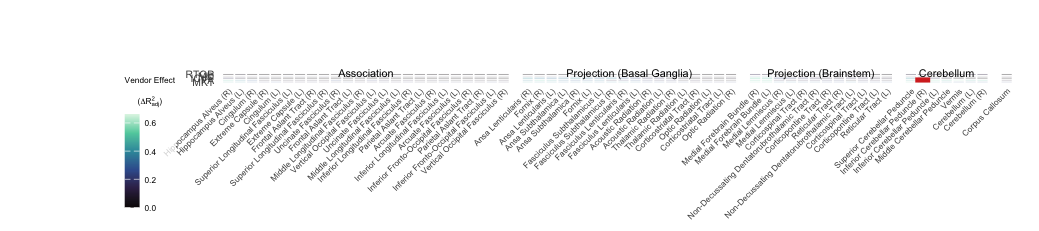

In [55]:
df_heat <- df_vendor_all %>%
  filter(
    source == "raw",
    qc_covariate == qc_target,
    metric %in% metrics_keep,
    !is.na(bundle), !is.na(bundle_category), !is.na(effect_size)
  ) %>%
  mutate(
    metric_label = unname(metric_labels[metric]),
    bundle_clean = bundle,
    bundle_category = case_when(
      bundle_category == "ProjectionBasalGanglia" ~ "Projection (Basal Ganglia)",
      bundle_category == "ProjectionBrainstem" ~ "Projection (Brainstem)",
      TRUE ~ bundle_category
    ),
    bundle_clean = bundle_clean %>%
      str_replace("FrontoOccipital", "Fronto-Occipital") %>%
      str_replace("NonDecussating", "Non-Decussating") %>%
      str_replace("L$", " (L)") %>%
      str_replace("R$", " (R)") %>%
      str_replace_all("(?<=[a-z])(?=[A-Z])", " ")
  )

if (nrow(df_heat) == 0) stop("No rows for Panel A (raw + no_quality + metrics_keep)")

metric_order <- df_heat %>%
  group_by(metric_label) %>%
  summarise(mean_effect = mean(effect_size, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(mean_effect)) %>%
  pull(metric_label)

df_heat$metric_label <- factor(df_heat$metric_label, levels = metric_order)

bundle_df <- df_heat %>%
  group_by(bundle_category, bundle_clean) %>%
  summarise(mean_effect = mean(effect_size, na.rm = TRUE), .groups = "drop") %>%
  mutate(bundle_category = factor(bundle_category, levels = category_order)) %>%
  arrange(bundle_category, desc(mean_effect), bundle_clean)

bundle_levels <- c()
for (cat in category_order) {
  cat_bundles <- bundle_df %>% filter(bundle_category == cat) %>% pull(bundle_clean)
  if (length(cat_bundles) > 0) {
    bundle_levels <- c(bundle_levels, cat_bundles, paste0("spacer_", cat))
  }
}
bundle_levels <- bundle_levels[!grepl("^spacer_Commissure$", bundle_levels)]

df_heat$bundle_clean <- factor(df_heat$bundle_clean, levels = bundle_levels)

highlight_bundle_patterns <- c(
  "Cerebellum_InferiorCerebellarPeduncleR",
  "InferiorCerebellarPeduncleR",
  "Cerebellum_InferiorCerebellarPeduncle",
  "InferiorCerebellarPeduncle"
)
highlight_bundle_pattern <- highlight_bundle_patterns[
  vapply(highlight_bundle_patterns, function(pat) any(str_detect(df_heat$bundle, fixed(pat))), logical(1))
][1]
if (is.na(highlight_bundle_pattern) || !nzchar(highlight_bundle_pattern)) {
  warning("Panel A highlight cell not found for right inferior cerebellar peduncle")
  highlight_cell <- df_heat[0, c("bundle_clean", "metric_label")]
} else {
  if (!str_detect(highlight_bundle_pattern, "PeduncleR")) {
    message("[WARN] Right-lateralized inferior cerebellar peduncle not available in panel A; using: ", highlight_bundle_pattern)
  }
  highlight_cell <- df_heat %>%
    filter(metric == "GQI_fa", str_detect(bundle, fixed(highlight_bundle_pattern))) %>%
    distinct(bundle_clean, metric_label)
}

spacer_df <- expand.grid(
  bundle_clean = bundle_levels[grepl("^spacer_", bundle_levels)],
  metric_label = metric_order
) %>%
  mutate(effect_size = NA_real_)

df_heat_plot <- bind_rows(
  df_heat %>% select(bundle_clean, metric_label, effect_size),
  spacer_df
)

x_labels <- levels(df_heat_plot$bundle_clean)
x_labels[grepl("^spacer_", x_labels)] <- ""

bundle_index_df <- tibble(bundle_clean = bundle_levels, index = seq_along(bundle_levels))
cat_positions <- bundle_df %>%
  group_by(bundle_category) %>%
  summarise(
    xmin = min(bundle_index_df$index[bundle_index_df$bundle_clean %in% bundle_clean]),
    xmax = max(bundle_index_df$index[bundle_index_df$bundle_clean %in% bundle_clean]),
    xmid = mean(c(xmin, xmax)),
    .groups = "drop"
  ) %>%
  filter(bundle_category != "Commissure")

heatmap_export_width_in <- figure_width_in
heatmap_final_width_in <- figure_width_in

p_panel_a <- ggplot(df_heat_plot, aes(x = bundle_clean, y = metric_label, fill = effect_size)) +
  geom_tile(color = "white", linewidth = 0.45, height = heatmap_tile_height) +
  geom_tile(data = highlight_cell, aes(x = bundle_clean, y = metric_label), fill = NA, color = "#D73027", linewidth = 0.9, width = 0.98, height = heatmap_tile_height, inherit.aes = FALSE) +
  scale_fill_viridis_c(
    option = "mako",
    name = expression(atop("Vendor Effect", "(" * Delta * R[adj]^2 * ")")),
    na.value = "white"
  ) +
  guides(fill = guide_colorbar(barheight = unit(length(metric_order) * heatmap_tile_height * 0.78, "lines"), barwidth = unit(0.62, "lines"))) +
  scale_x_discrete(labels = x_labels, expand = expansion(add = 0.8)) +
  scale_y_discrete(expand = expansion(mult = c(0, 0))) +
  coord_cartesian(clip = "off") +
  labs(x = NULL, y = NULL) +
  theme_minimal(
    base_family = font_family_use,
    base_size = pt_for_export(axis_text_pt, heatmap_export_width_in, heatmap_final_width_in)
  ) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = pt_for_export(5, heatmap_export_width_in, heatmap_final_width_in)),
    axis.text.y = element_text(size = pt_for_export(axis_text_pt + 0.2, heatmap_export_width_in, heatmap_final_width_in)),
    axis.ticks = element_blank(),
    plot.margin = margin(44, 14, 6, 112),
    legend.title = element_text(size = pt_for_export(5, heatmap_export_width_in, heatmap_final_width_in)),
    legend.text = element_text(size = pt_for_export(5, heatmap_export_width_in, heatmap_final_width_in)),
    legend.position = c(-0.12, 0.97),
    legend.justification = c(0, 1),
    legend.direction = "vertical",
    legend.margin = margin(1, 1, 1, 1),
    legend.background = element_rect(fill = scales::alpha("white", 0.76), color = NA),
    legend.box.background = element_blank(),
    panel.background = element_rect(fill = plot_style$panel_background_fill, color = NA),
    plot.background = element_rect(fill = plot_style$plot_background_fill, color = NA),
    panel.border = element_blank()
  )

y_top <- length(metric_order) + 0.82
for (i in seq_len(nrow(cat_positions))) {
  p_panel_a <- p_panel_a + annotate(
    "text",
    x = cat_positions$xmid[i],
    y = y_top,
    label = cat_positions$bundle_category[i],
    family = font_family_use,
    size = pt_for_export(axis_text_pt + 0.5, heatmap_export_width_in, heatmap_final_width_in) / .pt
  )
}

options(repr.plot.width = figure_width_in, repr.plot.height = heatmap_height_in, repr.plot.res = 120)

p_panel_a
save_plot_outputs(p_panel_a, "Figure3_panel_a_vendor_effect_heatmap", figure3_dir, figure_width_in, heatmap_height_in, allow_sans_fallback = FALSE)



## Panel B (Bottom Left): Vendor Effects Before vs After Harmonization

Line plot of mean vendor effects across bundles for the five core microstructural metrics (`qc_covariate = no_quality`), with an inset zoom around the harmonized cluster near zero.



[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure3/Figure3_panel_b_vendor_effect_lineplot.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure3/Figure3_panel_b_vendor_effect_lineplot.png



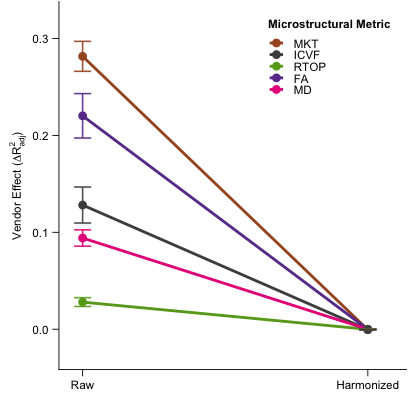

In [56]:
df_line <- df_vendor_all %>%
  filter(
    source %in% c("raw", "harmonized"),
    qc_covariate == qc_target,
    metric %in% metrics_keep,
    !is.na(bundle),
    !is.na(effect_size)
  ) %>%
  group_by(source, metric, bundle) %>%
  summarise(effect_size = mean(effect_size, na.rm = TRUE), .groups = "drop") %>%
  group_by(source, metric) %>%
  summarise(
    mean_effect = mean(effect_size, na.rm = TRUE),
    n_bundle = dplyr::n(),
    sem_effect = if_else(n_bundle > 1, sd(effect_size, na.rm = TRUE) / sqrt(n_bundle), as.numeric(NA)),
    .groups = "drop"
  ) %>%
  mutate(
    source = factor(source, levels = c("raw", "harmonized"), labels = c("Raw", "Harmonized")),
    metric_label = factor(recode(metric, !!!metric_labels), levels = unname(metric_labels)),
    source_num = as.numeric(source)
  )

if (nrow(df_line) == 0) stop("No rows for Panel B")

y_limits <- range(
  c(df_line$mean_effect - df_line$sem_effect, df_line$mean_effect + df_line$sem_effect),
  na.rm = TRUE,
  finite = TRUE
)
if (!all(is.finite(y_limits))) y_limits <- c(0, 0.05)
y_pad <- max(diff(y_limits) * 0.08, 0.004)
y_limits <- c(min(0, y_limits[1] - y_pad), y_limits[2] + y_pad)

panel_b_theme <- make_panel_theme(legend_position = c(0.98, 0.98), placed_width_in = panel_width_in)

p_line_main <- ggplot(df_line, aes(x = source_num, y = mean_effect, group = metric_label, color = metric_label)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.8) +
  geom_errorbar(aes(ymin = mean_effect - sem_effect, ymax = mean_effect + sem_effect), width = 0.06, linewidth = 0.45, alpha = 0.9) +
  scale_color_manual(values = metric_colors, name = "Microstructural Metric", drop = FALSE) +
  guides(color = guide_legend(ncol = 1, byrow = TRUE)) +
  scale_x_continuous(
    breaks = c(1, 2),
    labels = c("Raw", "Harmonized"),
    expand = expansion(mult = c(0.05, 0.1))
  ) +
  coord_cartesian(ylim = y_limits) +
  labs(
    x = NULL,
    y = expression("Vendor Effect (" * Delta * R[adj]^2 * ")")
  ) +
  panel_b_theme +
  theme(
    axis.line = element_line(linewidth = 0.25, color = "black"),
    axis.ticks = element_line(linewidth = 0.25, color = "black"),
    panel.grid.minor = element_blank(),
    legend.justification = c(1, 1),
    legend.direction = "vertical",
    legend.background = element_blank(),
    legend.box.background = element_blank(),
    legend.key.height = unit(7, "pt"),
    legend.key.width = unit(10, "pt"),
    axis.title = element_text(size = pt_for_export(7, panel_width_in, panel_width_in)),
    axis.text = element_text(size = pt_for_export(7, panel_width_in, panel_width_in)),
    legend.title = element_text(face = "bold", size = pt_for_export(7, panel_width_in, panel_width_in)),
    legend.text = element_text(size = pt_for_export(7, panel_width_in, panel_width_in)),
    plot.title = element_blank(),
    plot.margin = margin(1, 5.5, 5.5, 5.5)
  )

p_panel_b <- p_line_main

options(repr.plot.width = panel_width_in, repr.plot.height = panel_height_in, repr.plot.res = 120)

p_panel_b
save_plot_outputs(p_panel_b, "Figure3_panel_b_vendor_effect_lineplot", figure3_dir, panel_width_in, panel_height_in)



## Panel C (Bottom Right): GQI_fa Vendor Distributions

Violin plots of `GQI_fa` in `Cerebellum_InferiorCerebellarPeduncleR` (falling back to the closest available inferior cerebellar peduncle column if needed) across vendors for raw and harmonized data.



[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure3/Figure3_panel_c_gqi_fa_vendor_violin.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure3/Figure3_panel_c_gqi_fa_vendor_violin.png



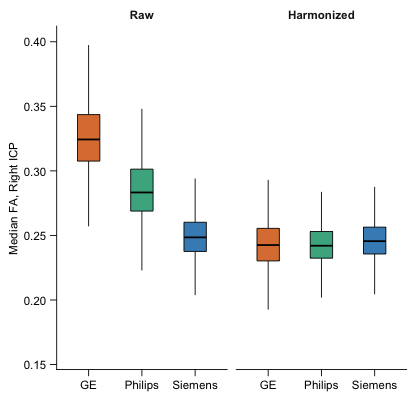

In [57]:
raw_path <- fs::path(project_root, "data", "raw_data", "merged_data_meisler_analyses.parquet")
harm_path <- fs::path(project_root, "data", "harmonized_data", "merged_data_meisler_analyses_harmonized.parquet")
if (!file_exists(raw_path)) stop("Missing raw parquet: ", raw_path)
if (!file_exists(harm_path)) stop("Missing harmonized parquet: ", harm_path)

bundle_col_candidates <- c(
  "bundle_Cerebellum_InferiorCerebellarPeduncleR_GQI_fa_median",
  "bundle_Cerebellum_InferiorCerebellarPeduncle_GQI_fa_median",
  "bundle_Cerebellum_InferiorCerebellarPeduncleR_GQI_fa_mean",
  "bundle_Cerebellum_InferiorCerebellarPeduncle_GQI_fa_mean"
)

raw_cols <- arrow::open_dataset(raw_path, format = "parquet")$schema$names
harm_cols <- arrow::open_dataset(harm_path, format = "parquet")$schema$names
shared_cols <- intersect(raw_cols, harm_cols)
bundle_col <- bundle_col_candidates[bundle_col_candidates %in% shared_cols][1]
if (is.na(bundle_col) || !nzchar(bundle_col)) {
  stop("Panel C bundle column not found. Checked: ", paste(bundle_col_candidates, collapse = ", "))
}
if (!grepl("PeduncleR", bundle_col)) {
  message("[WARN] Right-lateralized inferior cerebellar peduncle column not available; using: ", bundle_col)
}

read_panel_c <- function(path, source_label) {
  arrow::read_parquet(path, col_select = all_of(c("scanner_manufacturer", bundle_col))) %>%
    as_tibble() %>%
    transmute(
      source = factor(source_label, levels = c("Raw", "Harmonized")),
      vendor = factor(case_when(
        str_detect(str_to_lower(as.character(scanner_manufacturer)), "siemens") ~ "Siemens",
        str_detect(str_to_lower(as.character(scanner_manufacturer)), "philips") ~ "Philips",
        str_detect(str_to_lower(as.character(scanner_manufacturer)), "ge") ~ "GE",
        TRUE ~ NA_character_
      ), levels = c("GE", "Philips", "Siemens")),
      value = .data[[bundle_col]]
    ) %>%
    filter(!is.na(vendor), !is.na(value))
}

df_panel_c <- bind_rows(
  read_panel_c(raw_path, "Raw"),
  read_panel_c(harm_path, "Harmonized")
)
if (nrow(df_panel_c) == 0) stop("No rows for Panel C")
panel_c_ymin <- min(df_panel_c$value, na.rm = TRUE)
if (!is.finite(panel_c_ymin)) panel_c_ymin <- 0
if (panel_c_ymin >= 0.4) panel_c_ymin <- 0.35

p_panel_c <- ggplot(df_panel_c, aes(x = vendor, y = value, fill = vendor)) +
  geom_boxplot(width = 0.42, outlier.shape = NA, alpha = 0.82, color = "black", linewidth = 0.25) +
  facet_wrap(~source, nrow = 1) +
  scale_fill_manual(values = vendor_colors, limits = c("GE", "Philips", "Siemens"), drop = FALSE) +
  coord_cartesian(ylim = c(panel_c_ymin, 0.4)) +
  labs(x = NULL, y = "Median FA, Right ICP") +
  make_panel_theme(legend_position = "none", placed_width_in = panel_width_in) +
  theme(
    axis.line = element_line(linewidth = 0.25, color = "black"),
    axis.ticks = element_line(linewidth = 0.25, color = "black"),
    panel.grid.minor = element_blank(),
    strip.background = element_blank(),
    strip.text = element_text(size = pt_for_export(7, panel_width_in, panel_width_in), face = "bold"),
    axis.title.y = element_text(size = pt_for_export(7, panel_width_in, panel_width_in)),
    axis.text.x = element_text(size = pt_for_export(7, panel_width_in, panel_width_in)),
    axis.text.y = element_text(size = pt_for_export(7, panel_width_in, panel_width_in)),
    plot.margin = margin(1, 5.5, 5.5, 5.5)
  )

options(repr.plot.width = panel_width_in, repr.plot.height = panel_height_in, repr.plot.res = 120)

p_panel_c
save_plot_outputs(p_panel_c, "Figure3_panel_c_gqi_fa_vendor_violin", figure3_dir, panel_width_in, panel_height_in)



## ABC Layout Preview

Preview layout with panel A full-width on top and panels B/C side-by-side on the bottom row.



[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure3/Figure3_combined_abc_preview.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure3/Figure3_combined_abc_preview.png



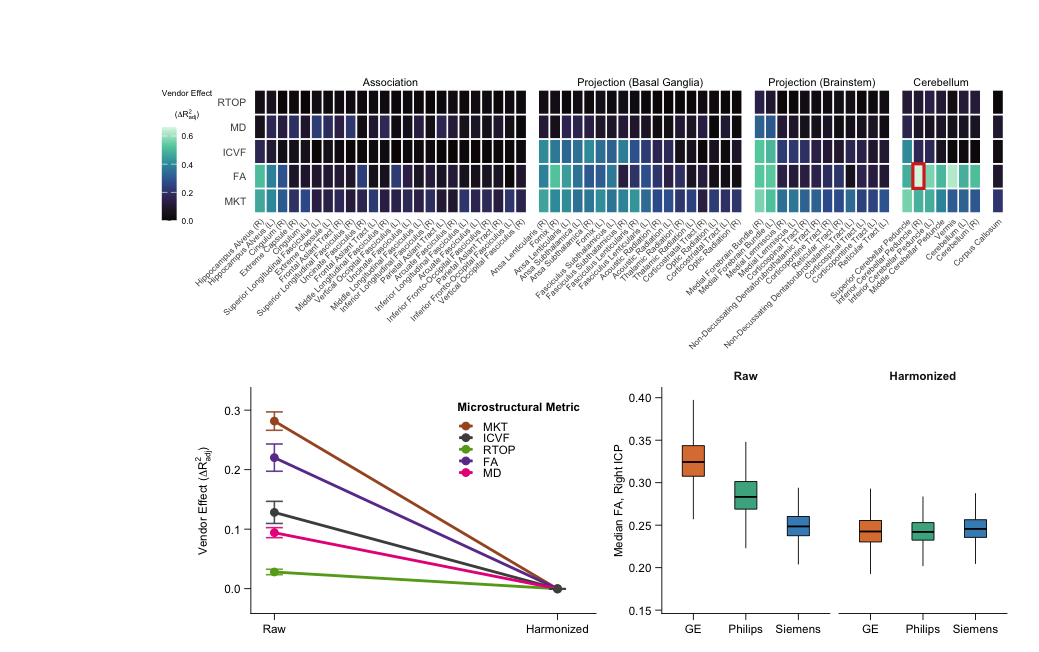

In [58]:
figure3_abc <- (p_panel_a / (p_panel_b | p_panel_c)) +
  patchwork::plot_layout(heights = c(heatmap_height_in, panel_height_in), widths = c(1, 1))

combined_height_in <- min(figure_height_max_mm / 25.4, heatmap_height_in + panel_height_in + 0.18)

options(repr.plot.width = figure_width_in, repr.plot.height = combined_height_in, repr.plot.res = 120)

figure3_abc
save_plot_outputs(figure3_abc, "Figure3_combined_abc_preview", figure3_dir, figure_width_in, combined_height_in)

